In [1]:
import os
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

def make_combination(config_dict):
    keys, values = zip(*config_dict.items())
    return [dict(zip(keys, v)) for v in itertools.product(*values)]

In [2]:
UEA_MTSC30 = ['EthanolConcentration',
              'FaceDetection',
              'Handwriting',
              'Heartbeat',
              'JapaneseVowels',
              'PEMS-SF',
              'SelfRegulationSCP1',
              'SelfRegulationSCP2',
              'SpokenArabicDigits',
              'UWaveGestureLibrary',
              'ArticularyWordRecognition',
              'AtrialFibrillation',
              'BasicMotions',
              'CharacterTrajectories',
              'Cricket',
              'DuckDuckGeese',
              'EigenWorms',
              'Epilepsy',
              'ERing',
              'FingerMovements',
              'HandMovementDirection',
              'InsectWingbeat',
              'Libras',
              'LSST',
              'MotorImagery',
              'NATOPS',
              'PenDigits',
              'PhonemeSpectra',
              'RacketSports',
              'StandWalkJump']

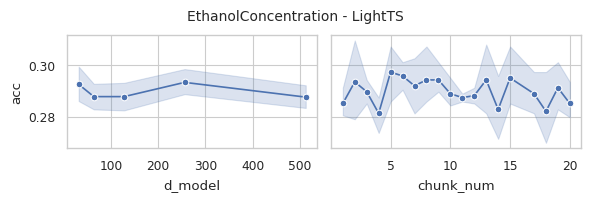

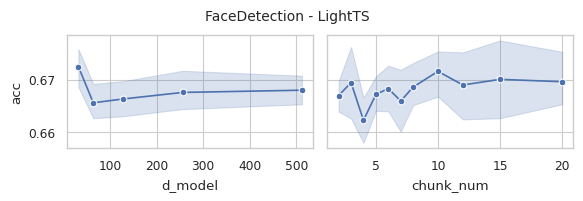

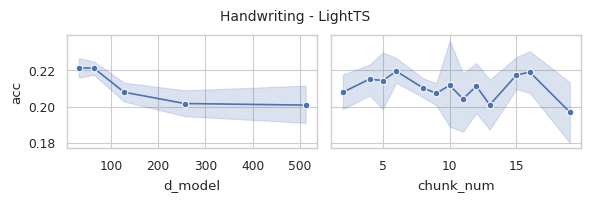

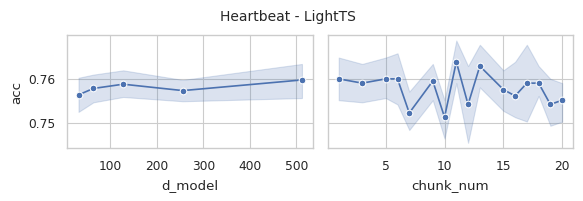

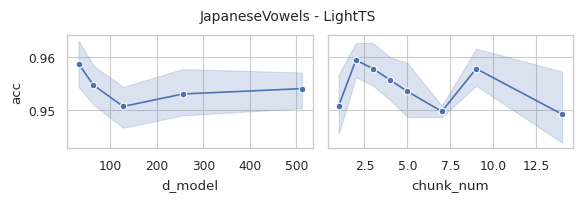

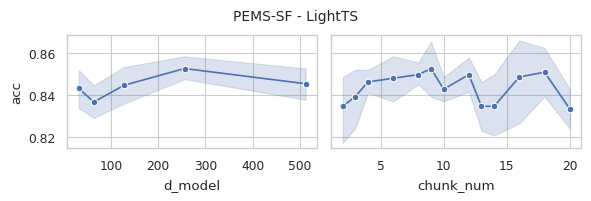

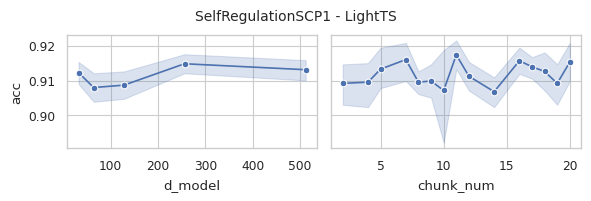

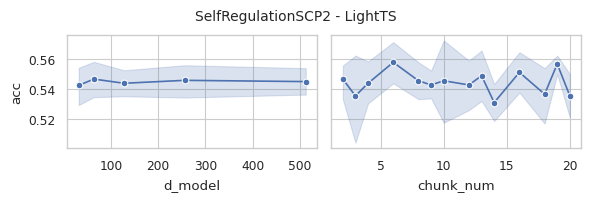

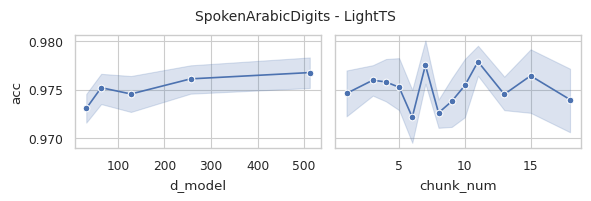

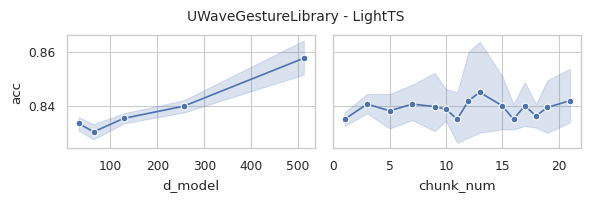

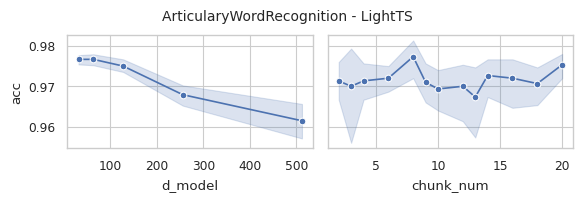

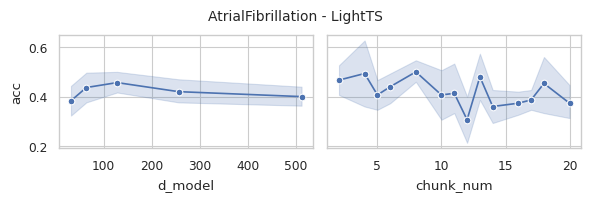

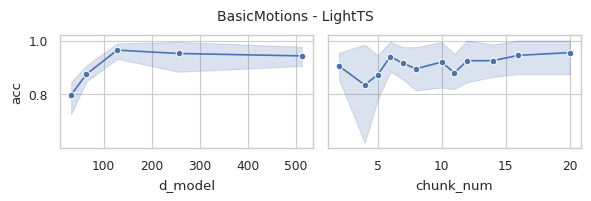

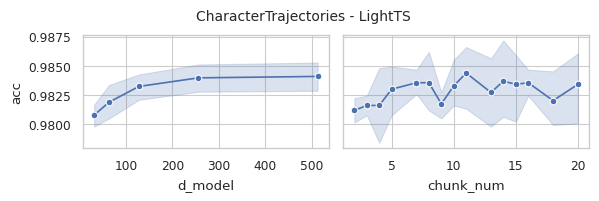

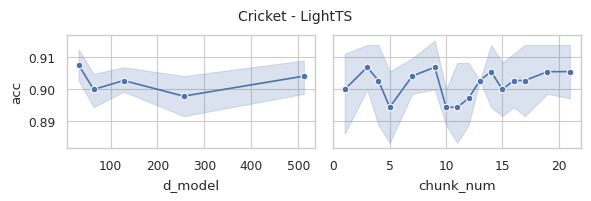

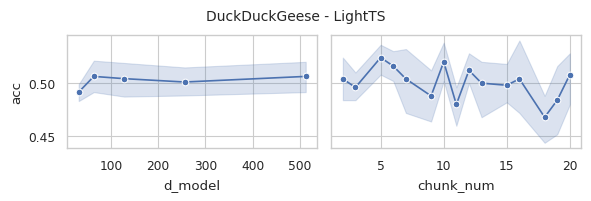

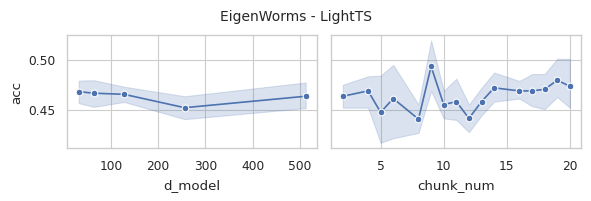

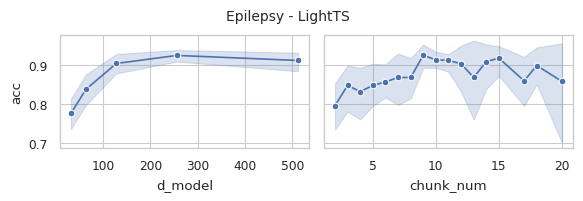

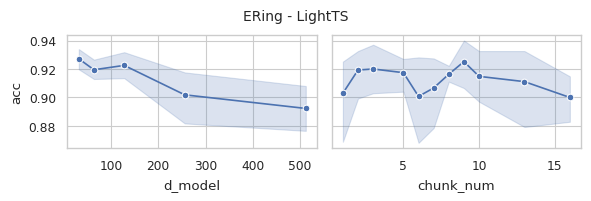

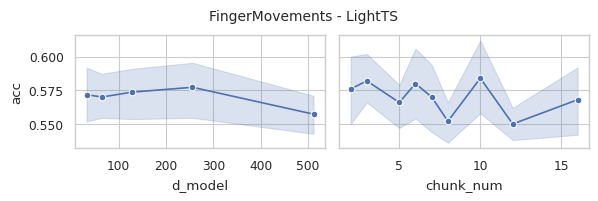

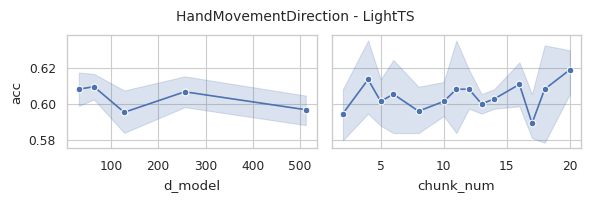

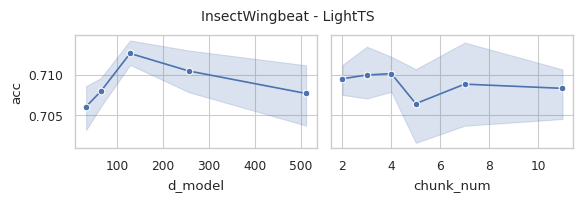

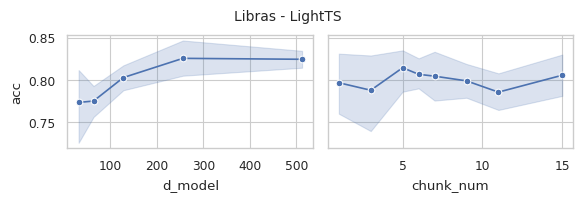

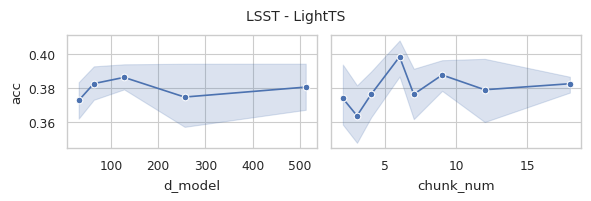

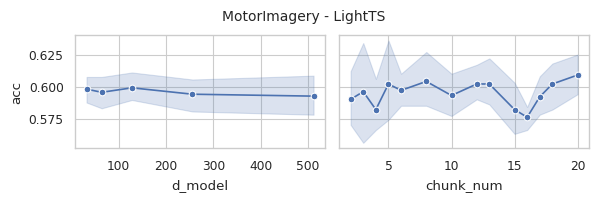

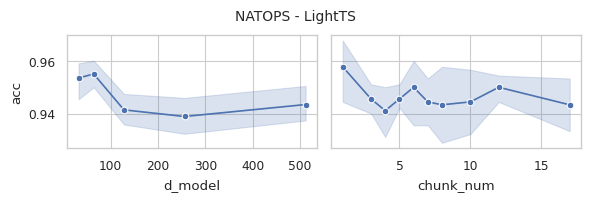

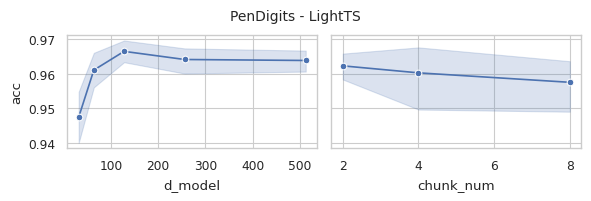

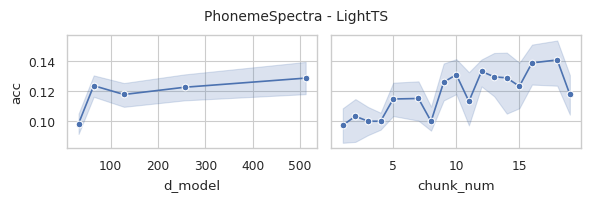

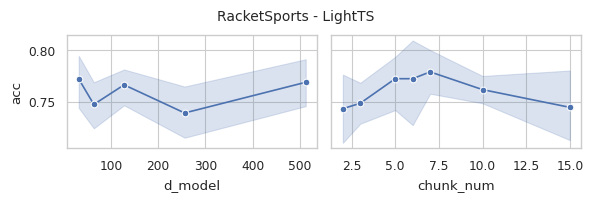

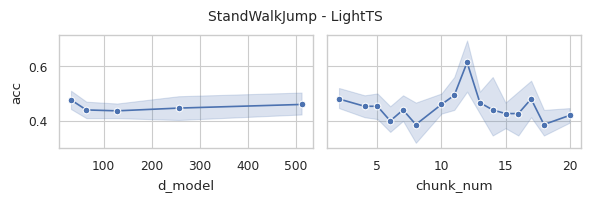

In [3]:
model = 'LightTS'
result_dict = dict()

for data_name in UEA_MTSC30:
    
    if os.path.exists(f'../03-full_results/{model}/{model}_CLS_{data_name}.out'):
        with open(f'../03-full_results/{model}/{model}_CLS_{data_name}.out', 'r') as file:
            data = file.read().splitlines()
    else:
        print('no file')
        continue


    result_lst = list()
    for i in range(len(data)):
        if data[i].startswith('>>>>>>>testing : '):
            data_meta = list(data[i][16:-33].split('_'))
            data_meta[6] = int(data_meta[6].replace('sl', ''))
            data_meta[7] = int(data_meta[7].replace('ll', ''))
            data_meta[8] = int(data_meta[8].replace('pl', ''))
            data_meta[9] = int(data_meta[9].replace('dm', ''))
            data_meta[10] = int(data_meta[10].replace('cs', ''))

            acc = data[i+3].replace('accuracy:', '')
            model_params = data[i+4].replace('model parameter : ', '')
            model_size = data[i+5].replace('model size : ', '').replace('MB', '')

            result_data = {
                # 'task': data_meta[0],
                # 'model_id': data_meta[1],
                'data_name': data_meta[2],
                'model': data_meta[3],
                # 'data': data_meta[4],
                # 'feature': data_meta[5],
                'seq_len': data_meta[6],
                # 'label_len': data_meta[7],
                # 'pred_len': data_meta[8],
                'd_model': data_meta[9],
                'chunk_size': data_meta[10],
                'chunk_num': data_meta[6] // data_meta[10],
                # 'exp': data_meta[11],
                # 'desc': data_meta[12],
                'acc': float(acc),
                'model_params': int(model_params),
                'model_size (MB)': float(model_size)
            }

            result_lst.append(result_data)

    result_df = pd.DataFrame(result_lst)
    os.makedirs(f'./{model}', exist_ok=True)
    result_df.to_csv(f'./{model}/{data_name}.csv', index=False)
    result_dict[data_name] = result_df

    cols = ['d_model', 'chunk_num']
    num_cols, num_rows = 2, 1
    
    # # Boxplot
    # sns.set_theme(style="whitegrid")
    # sns.set_context("paper", font_scale=1)
    # fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(6, 2), sharey=True)
    # for i, col in enumerate(cols):
    #     sns.boxplot(x=col, y='acc', data=result_df, ax=axs[i%num_cols], legend=False)
    # fig.suptitle(f'{data_name} - {model}', fontsize=10)
    # plt.tight_layout()
    # plt.subplots_adjust(top=0.85)
    # display(fig)
    # plt.close(fig)

    # Lineplot
    sns.set_theme(style="whitegrid")
    sns.set_context("paper", font_scale=1)
    fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(6, 2), sharey=True)
    for i, col in enumerate(cols):
        sns.lineplot(x=col, y='acc', data=result_df, ax=axs[i%num_cols], legend=False, style='model', markers=True)
    fig.suptitle(f'{data_name} - {model}', fontsize=10)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    display(fig)
    plt.savefig(f'./{model}/{data_name}.png', dpi=300, bbox_inches='tight')
    plt.close(fig)
    

    # # Lineplot where each line represents same hyperparameter combination except one
    # fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(6, 2), sharey=True)
    # for i, col in enumerate(cols):
    #     col_rest = [c for c in cols if c != col]
    #     tmp_result = result_df.pivot_table(index=col_rest, columns=col, values='acc')
    #     tmp_result = pd.DataFrame(tmp_result.values, columns=tmp_result.columns)
    #     max_idx = tmp_result.mean(axis=1).idxmax()
    #     axs[i%num_cols].plot(tmp_result.T, marker='.', color='#111', alpha=0.2)
    #     axs[i%num_cols].plot(tmp_result.iloc[max_idx].T, marker='o', color='red', alpha=0.5)
    #     axs[i%num_cols].grid(False)
    #     axs[i%num_cols].set_xlabel(col)
    # fig.suptitle(f'{data_name} - {model}', fontsize=10)
    # plt.tight_layout()
    # plt.subplots_adjust(top=0.85)
    # display(fig)
    # plt.close(fig)
    
    

In [4]:
model_configs = {
        "d_model" : [32, 64, 128, 256, 512],
        "num_chunks" : range(2, 22),
}

hyperparameter_combinations = make_combination(model_configs)

acc_all_df = pd.DataFrame(index=UEA_MTSC30)
for data_name in UEA_MTSC30:
    for hyperparameter_combination in hyperparameter_combinations:
        d_model = hyperparameter_combination['d_model']
        num_chunks = hyperparameter_combination['num_chunks']

        if result_dict.get(data_name) is None:
            continue
        
        tmp = result_dict[data_name]
        try:
            acc = tmp[
                (tmp['d_model'] == d_model)
                & (tmp['chunk_size'] == math.ceil(tmp["seq_len"].values[0] / num_chunks))
            ]['acc'].values[0]
        except:
            acc = None
            print(f'no acc for {data_name} with {hyperparameter_combination}')
        acc_all_df.loc[data_name, str(hyperparameter_combination)] = acc



In [5]:
acc_all_df.loc[:,'max'] = acc_all_df.max(axis=1)
acc_all_df.loc['avg'] = acc_all_df.mean(axis=0)
acc_all_df.sort_values(by='avg', ascending=False, inplace=True, axis=1)
acc_all_df

/tmp/ipykernel_1663512/684517580.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  acc_all_df.loc[:,'max'] = acc_all_df.max(axis=1)


,max,"{'d_model': 512, 'num_chunks': 7}","{'d_model': 64, 'num_chunks': 4}","{'d_model': 128, 'num_chunks': 13}","{'d_model': 128, 'num_chunks': 11}","{'d_model': 64, 'num_chunks': 10}","{'d_model': 512, 'num_chunks': 13}","{'d_model': 256, 'num_chunks': 5}","{'d_model': 256, 'num_chunks': 4}","{'d_model': 256, 'num_chunks': 8}",...,"{'d_model': 64, 'num_chunks': 13}","{'d_model': 32, 'num_chunks': 13}","{'d_model': 32, 'num_chunks': 21}","{'d_model': 64, 'num_chunks': 3}","{'d_model': 32, 'num_chunks': 18}","{'d_model': 32, 'num_chunks': 19}","{'d_model': 32, 'num_chunks': 3}","{'d_model': 256, 'num_chunks': 6}","{'d_model': 32, 'num_chunks': 15}","{'d_model': 32, 'num_chunks': 4}"
EthanolConcentration,0.323194,0.296578,0.285171,0.292776,0.300380,0.292776,0.292776,0.288973,0.300380,0.296578,...,0.285171,0.285171,0.277567,0.296578,0.273764,0.266160,0.323194,0.281369,0.285171,0.285171
FaceDetection,0.684733,0.670545,0.666005,0.658627,0.671112,0.663451,0.674801,0.662599,0.684733,0.669410,...,0.673666,0.676504,0.680477,0.663734,0.681328,0.681328,0.671680,0.665153,0.676504,0.671964
Handwriting,0.250588,0.216471,0.218824,0.209412,0.212941,0.216471,0.183529,0.223529,0.202353,0.204706,...,0.231765,0.223529,0.208235,0.211765,0.223529,0.208235,0.221176,0.192941,0.220000,0.222353
Heartbeat,0.775610,0.756098,0.760976,0.765854,0.756098,0.756098,0.736585,0.756098,0.751220,0.751220,...,0.765854,0.751220,0.746341,0.746341,0.775610,0.756098,0.751220,0.756098,0.765854,0.760976
JapaneseVowels,0.967568,0.954054,0.954054,0.954054,0.954054,0.959459,0.956757,0.959459,0.954054,0.948649,...,0.959459,0.954054,0.964865,0.964865,0.964865,0.964865,0.959459,0.951351,0.964865,0.967568
PEMS-SF,0.878613,0.855491,0.843931,0.861272,0.832370,0.832370,0.838150,0.855491,0.855491,0.843931,...,0.843931,0.861272,0.849711,0.849711,0.843931,0.843931,0.815029,0.861272,0.820809,0.838150
SelfRegulationSCP1,0.928328,0.921502,0.911263,0.907850,0.901024,0.911263,0.918089,0.911263,0.911263,0.907850,...,0.911263,0.914676,0.904437,0.890785,0.914676,0.911263,0.914676,0.924915,0.904437,0.911263
SelfRegulationSCP2,0.594444,0.544444,0.572222,0.500000,0.544444,0.544444,0.577778,0.544444,0.583333,0.555556,...,0.522222,0.522222,0.555556,0.516667,0.533333,0.572222,0.477778,0.538889,0.516667,0.522222
SpokenArabicDigits,0.982265,0.969986,0.972715,0.978627,0.978172,0.977717,0.977717,0.979991,0.976808,0.978172,...,0.975898,0.976353,0.974079,0.979081,0.968622,0.974079,0.977717,0.971351,0.971805,0.972715
UWaveGestureLibrary,0.890625,0.853125,0.837500,0.840625,0.834375,0.821875,0.878125,0.843750,0.843750,0.846875,...,0.825000,0.825000,0.834375,0.831250,0.831250,0.831250,0.846875,0.837500,0.837500,0.837500


In [6]:
pd.set_option("display.precision", 14)
acc_all_df.iloc[:,[0,1]]*100

,max,"{'d_model': 512, 'num_chunks': 7}"
EthanolConcentration,32.31939163498099,29.65779467680608
FaceDetection,68.47332576617480,67.05448354143019
Handwriting,25.05882352941177,21.64705882352941
Heartbeat,77.56097560975610,75.60975609756098
JapaneseVowels,96.75675675675676,95.40540540540540
PEMS-SF,87.86127167630057,85.54913294797689
SelfRegulationSCP1,92.83276450511946,92.15017064846417
SelfRegulationSCP2,59.44444444444444,54.44444444444444
SpokenArabicDigits,98.22646657571623,96.99863574351978
UWaveGestureLibrary,89.06250000000000,85.31250000000000
